**Import Data from Google Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Data Cleaning & Preprocessing**

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
ecommerce_retail = pd.read_excel("/content/drive/MyDrive/Python Final Project/ecommerce retail.xlsx", sheet_name = 0)
segmentation = pd.read_excel("/content/drive/MyDrive/Python Final Project/ecommerce retail.xlsx", sheet_name = 1)

In [3]:
# Print the first five rows of the dataset
ecommerce_retail.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Check the general information of df
ecommerce_retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [5]:
# Check Data Summary
ecommerce_retail.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [6]:
# Check unique values of key categorical columns
ecommerce_retail[['StockCode', 'Description', 'CustomerID', 'Country']].nunique()

,0
StockCode,4070
Description,4223
CustomerID,4372
Country,38


**Exploratory Data Analysis (EDA)**

**Step 1. Convert to correct Data type**

To ensure proper grouping and time-based analysis, identifier columns were converted to string format and the date column was standardized.


In [7]:
# Convert selected columns to string type
column_list = ["InvoiceNo", "StockCode", "Description", "CustomerID", "Country"]
for c in column_list:
    ecommerce_retail[c] = ecommerce_retail[c].astype(str)

# Convert InvoiceDate to datetime format
ecommerce_retail['InvoiceDate'] = pd.to_datetime(ecommerce_retail['InvoiceDate'])

In [8]:
ecommerce_retail.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

**Step 2. Removing Invalid Transactions**

To ensure revenue accuracy, invalid records were removed using business logic rules.


In [9]:
# 1. Remove canceled orders (InvoiceNo starting with 'C')
ecommerce_retail = ecommerce_retail[~ecommerce_retail['InvoiceNo'].str.startswith("C")]

# 2. Remove transactions with Quantity < 0 where InvoiceNo does not start with 'C' (due to incorrect descriptions)
ecommerce_retail = ecommerce_retail[ecommerce_retail['Quantity'] > 0]

# 3. Remove transactions with UnitPrice < 0
ecommerce_retail = ecommerce_retail[ecommerce_retail['UnitPrice'] > 0]

**Step 3. Checking Missing Values in Error Column**

             volume          %
InvoiceNo         0   0.000000
StockCode         0   0.000000
Description       0   0.000000
Quantity          0   0.000000
InvoiceDate       0   0.000000
UnitPrice         0   0.000000
CustomerID   132220  24.942275
Country           0   0.000000


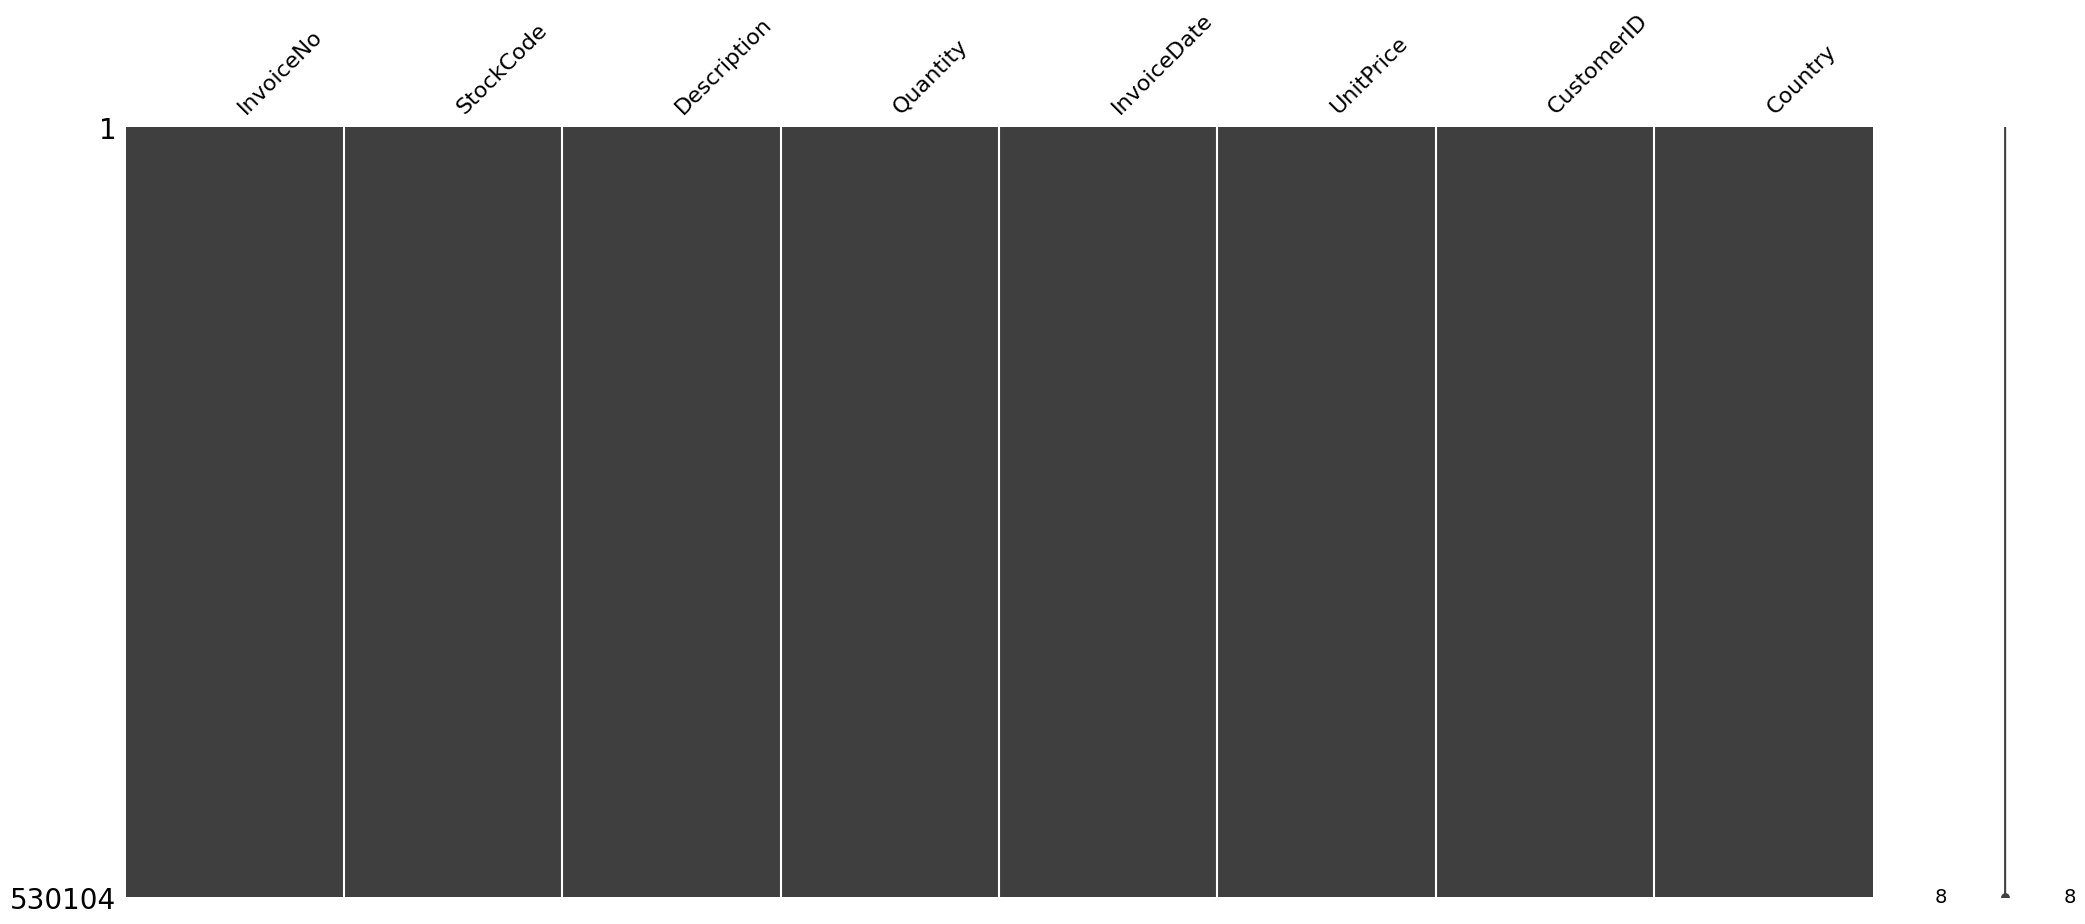

In [10]:
import missingno as msno
import numpy as np

# Visualize missing data
msno.matrix(ecommerce_retail)

# Standardize missing formats
ecommerce_retail["CustomerID"] = (
    ecommerce_retail["CustomerID"]
    .replace(["nan", "", " "], np.nan))

# Missing value summary
missing_summary = pd.DataFrame({
    "volume": ecommerce_retail.isnull().sum(),
    "%": (ecommerce_retail.isnull().sum() / ecommerce_retail.shape[0]) * 100})

print(missing_summary)

In [11]:
# Remove transactions with missing CustomerID to ensure valid customer-level analysis
ecommerce_retail = ecommerce_retail.dropna(subset=["CustomerID"])

**Step 4. Handle duplicate**

In [12]:
# Identify duplicate rows based on 'InvoiceNo', 'StockCode', 'InvoiceDate', and 'CustomerID'
ecommerce_duplicate = ecommerce_retail[
    ecommerce_retail.duplicated(
        subset=["InvoiceNo", "StockCode", "InvoiceDate", "CustomerID"])]

**Apply RFM Model**


**Step 1. RFM Feature Engineering**

In [13]:
# Set the reference date for calculating Recency as December 31, 2011
last_date = pd.to_datetime('12/31/2011')

# Calculate the Revenue column
ecommerce_retail['Revenue'] = ecommerce_retail['Quantity'] * ecommerce_retail['UnitPrice']

# Create RFM df
rfm = ecommerce_retail.groupby('CustomerID').agg(
    Recency=("InvoiceDate", lambda x: (last_date - x.max()).days), # Calculate the number of days since the last purchase
    Frequency=("InvoiceNo", "nunique"), # Count the number of transactions per customer
    Monetary=("Revenue", "sum") # Sum the total revenue per customer
).reset_index()

#Check
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,346,1,77183.60
1,12347.0,23,7,4310.00
2,12348.0,96,4,1797.24
3,12349.0,39,1,1757.55
4,12350.0,331,1,334.40


**Step 2. Check outlier**

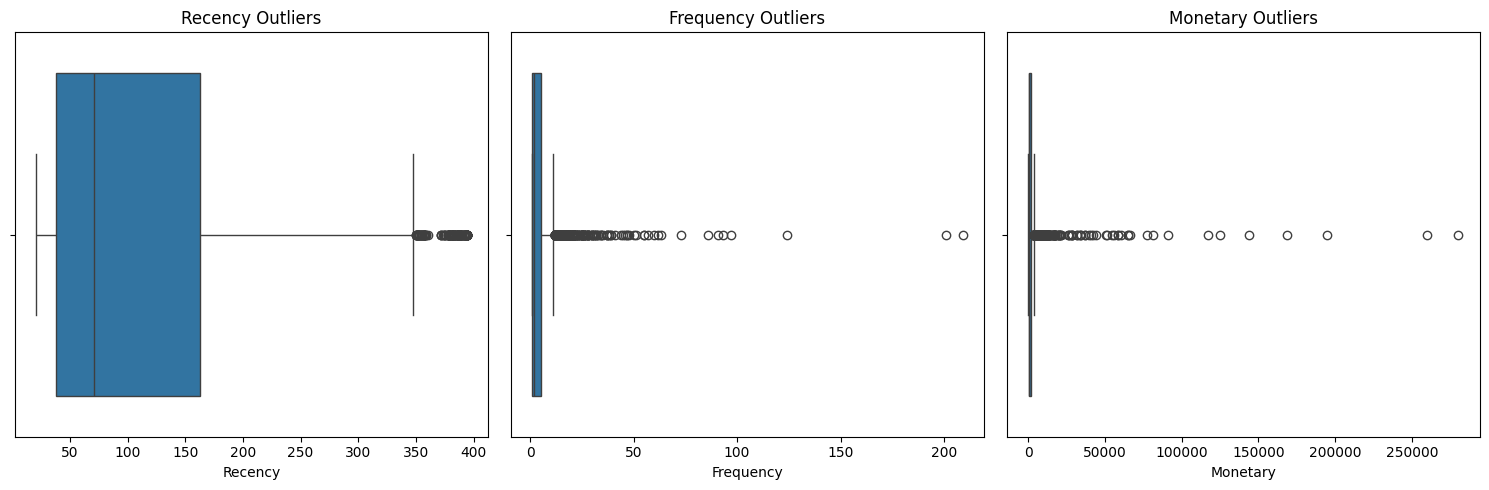

In [14]:
# Create 1 row, 3 columns
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Check outliers for the 'Recency' column
sns.boxplot(data=rfm, x='Recency', ax=axes[0])
axes[0].set_title('Recency Outliers')

# Check outliers for the 'Frequency' column
sns.boxplot(data=rfm, x='Frequency', ax=axes[1])
axes[1].set_title('Frequency Outliers')

# Check outliers for the 'Monetary' column
sns.boxplot(data=rfm, x='Monetary', ax=axes[2])
axes[2].set_title('Monetary Outliers')

plt.tight_layout()
plt.show()

📌 Solution

The boxplots show the presence of extreme values and right-skewed distributions, especially in Frequency and Monetary.

To ensure more reliable analysis, a 95th percentile threshold will be applied to remove extreme outliers. This allows the analysis to focus on the majority of customers and prevents distortion caused by unusually large values.

**Step 2.1. Outlier Treatment using 95th Percentile**

In [15]:
# Apply 95th percentile cap
rfm['Frequency'] = rfm['Frequency'].clip(upper=rfm['Frequency'].quantile(0.95))
rfm['Monetary'] = rfm['Monetary'].clip(upper=rfm['Monetary'].quantile(0.95))

**Step 3. Assign RFM scores using Qcut**

In [16]:
# Recency score: Lower values indicate more recent purchases, so assign higher scores to lower recency values
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels = [5,4,3,2,1])

# Frequency score: Higher values indicate more frequent purchases, so assign higher scores to higher frequency values
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels = [1,2,3,4,5])

# Monetary score: Higher values indicate higher spending, so assign higher scores to higher monetary values
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels = [1,2,3,4,5])

# Combine RFM scores into a single string to create the RFM segment
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346.0,346,1,5841.843,1,1,5,115
1,12347.0,23,7,4310.000,5,5,5,555
2,12348.0,96,4,1797.240,2,4,4,244
3,12349.0,39,1,1757.550,4,1,4,414
4,12350.0,331,1,334.400,1,1,2,112


**Step 4. Calculate RFM Score**

In [17]:
#Split the RFM Score column into a list
segmentation['RFM Score'] = segmentation['RFM Score'].astype(str).str.split(',')

In [18]:
#Explode (each score into a separate row)
segmentation = segmentation.explode('RFM Score')

In [19]:
#Remove whitespace from RFM_Score values
segmentation['RFM Score'] = segmentation['RFM Score'].str.strip()

In [20]:
#Merge segmentation into rfm
rfm = rfm.merge(segmentation, left_on="RFM_Score", right_on="RFM Score", how="left")

In [21]:
# After merging, remove the RFM column to prevent confusion
rfm = rfm.drop(columns=['RFM Score'])

In [22]:
# Display the final RFM segmentation table
rfm[['CustomerID', 'RFM_Score', 'Segment']].head()

,CustomerID,RFM_Score,Segment
0,12346.0,115,Cannot Lose Them
1,12347.0,555,Champions
2,12348.0,244,At Risk
3,12349.0,414,Promising
4,12350.0,112,Lost customers


In [23]:
#Final results table for RFM Scoring
#Generates the combined RFM_Score by concatenating the individual Recency, Frequency, and Monetary scores into a single string.
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,12346.0,346,1,5841.843,1,1,5,115,Cannot Lose Them
1,12347.0,23,7,4310.000,5,5,5,555,Champions
2,12348.0,96,4,1797.240,2,4,4,244,At Risk
3,12349.0,39,1,1757.550,4,1,4,414,Promising
4,12350.0,331,1,334.400,1,1,2,112,Lost customers
...,...,...,...,...,...,...,...,...,...
4333,18280.0,298,1,180.600,1,2,1,121,Lost customers
4334,18281.0,201,1,80.820,1,2,1,121,Lost customers
4335,18282.0,28,2,178.050,5,3,1,531,Potential Loyalist
4336,18283.0,24,13,2094.880,5,5,5,555,Champions


**Visualization & Analysis**


In [24]:
# Set Visualization Style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Define Custom Color Palette
# Set palette
Brand_color = "#4A90E2"

def brand_palette(n, reverse=False):
    return sns.light_palette(Brand_color, n_colors=n, reverse=reverse)

**A. Customer Segmentation Overview**

Understanding the distribution and behavioral characteristics of each RFM customer segment.

**1. Customer Count by Segment**

Visualize the number of customers in each RFM segment

/tmp/ipykernel_262/568714162.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


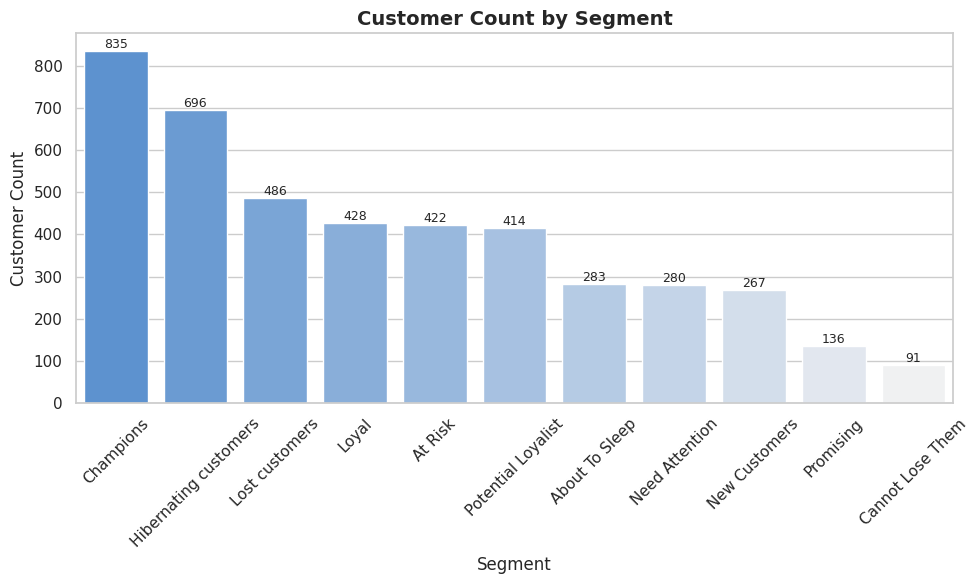

In [25]:
# Customer Count by Segment

order = rfm['Segment'].value_counts().index
palette = brand_palette(len(order), reverse=True)

ax = sns.countplot(
    data=rfm,
    x='Segment',
    order=order,
    palette=palette
)

# Add value labels
for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Customer Count by Segment", fontsize=14, weight='bold')
plt.xlabel("Segment")
plt.ylabel("Customer Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📌 Insight

- **Champions account for 835 customers (~20% of the total base)**, making it the largest segment and a strong foundation for retention-driven growth.

- **Hibernating customers represent 696 customers (~16%)**, while  
  **Lost customers account for about 480 (~11–12%)**.

- Inactive segments (**Hibernating + Lost**) together make up roughly **27% of the customer base**, indicating meaningful churn risk and a clear opportunity for reactivation strategies.

**2. Revenue Contribution by Segment**

Calculate total revenue generated by each customer segment


/tmp/ipykernel_262/3704572293.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


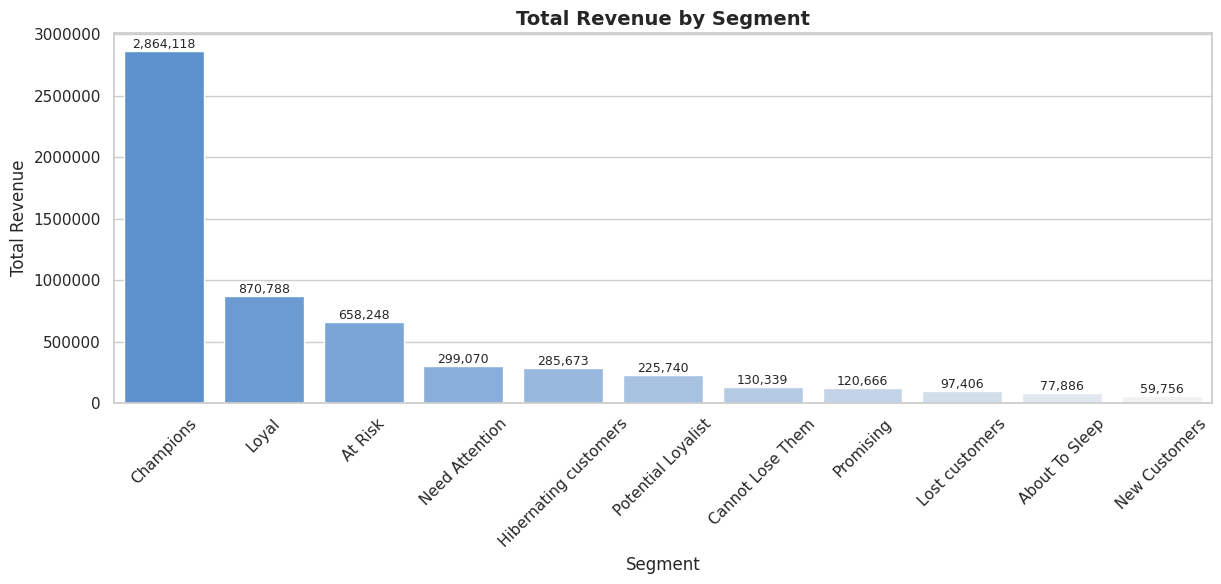

In [26]:
# Revenue Contribution by Segment

plt.figure(figsize=(12,6))

segment_rev = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

palette = brand_palette(len(segment_rev), reverse=True)

ax = sns.barplot(
    data=segment_rev,
    x='Segment',
    y='Monetary',
    palette=palette
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Total Revenue by Segment", fontsize=14, weight='bold')
plt.xlabel("Segment")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
ax.ticklabel_format(style='plain', axis='y')
plt.show()

### 📌 Insight  

- **Champions generate 2.86M in revenue**, contributing the largest share and serving as the primary revenue engine of the business.  

- **Loyal and At Risk segments together contribute over 1.5M**, forming a strong but retention-sensitive revenue base.  

- Revenue is heavily concentrated in top-tier customers, indicating high dependency on core high-value segments.

**3. Revenue Share by Segment (%)**

Show the percentage contribution of each segment to total revenue

/tmp/ipykernel_262/3356820586.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


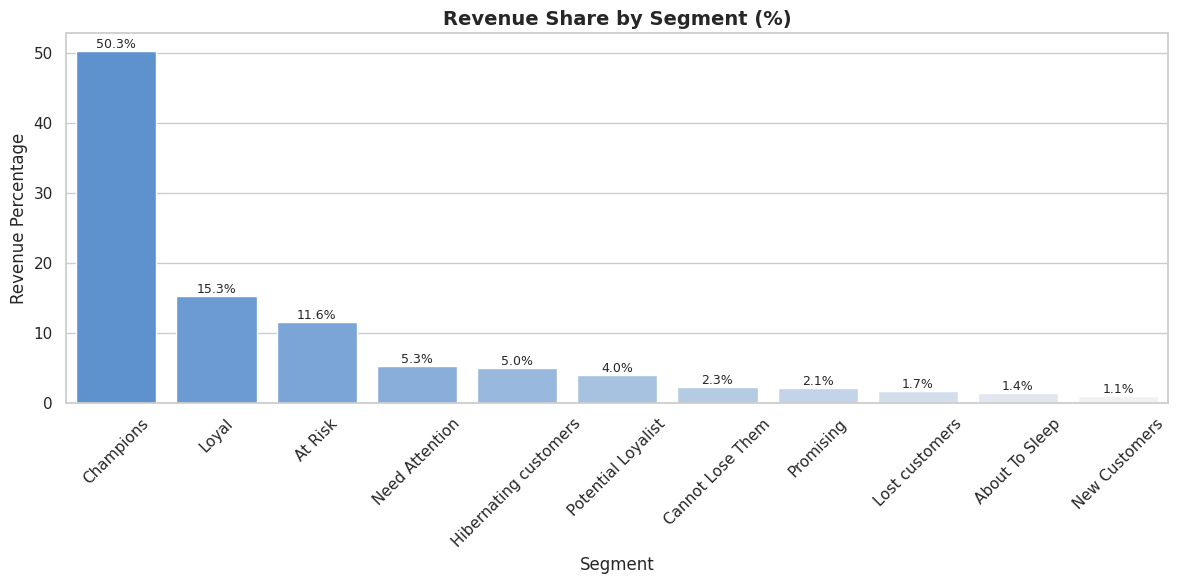

In [27]:
# Revenue Share by Segment (%)

plt.figure(figsize=(12,6))

segment_rev['Revenue_%'] = (
    segment_rev['Monetary'] /
    segment_rev['Monetary'].sum()
) * 100

palette = brand_palette(len(segment_rev), reverse=True)

ax = sns.barplot(
    data=segment_rev,
    x='Segment',
    y='Revenue_%',
    palette=palette
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():.1f}%',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Revenue Share by Segment (%)", fontsize=14, weight='bold')
plt.xlabel("Segment")
plt.ylabel("Revenue Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📌 Insight  

- **Champions contribute 50.3% of total revenue**, indicating a strong dependence on top-tier customers as the primary revenue driver.  

- **Loyal (15.3%) and At Risk (11.6%)** together account for nearly **27%**, representing a substantial but retention-sensitive revenue base.  

- All remaining segments individually contribute below 6%, highlighting a highly concentrated revenue structure.

**4. Average RFM Heatmap by Segment**

Compare average Recency, Frequency, and Monetary values across segments

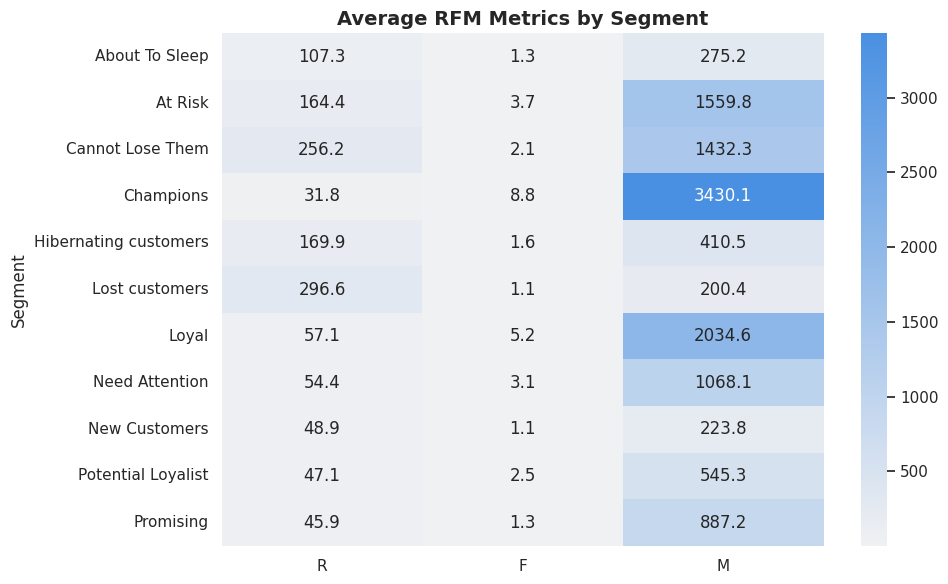

In [28]:
# Average RFM Metrics by Segment

plt.figure(figsize=(10,6))

segment_avg = (
    rfm.groupby('Segment')[['Recency','Frequency','Monetary']]
    .mean()
)

# Rename columns to RFM
segment_avg.columns = ['R', 'F', 'M']

sns.heatmap(
    segment_avg,
    annot=True,
    fmt=".1f",
    cmap=sns.light_palette(Brand_color, as_cmap=True)
)

plt.title("Average RFM Metrics by Segment", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

### 📌 Insight  

- **Champions show the strongest engagement**, with the lowest Recency (31.8), highest Frequency (8.8), and highest Monetary value (3430.1), confirming them as the most valuable and active segment.  

- **At Risk customers still generate high Monetary value (1559.8)** despite high Recency (164.4), indicating significant revenue at potential churn risk.  

- **Lost customers exhibit the weakest performance** (Recency 296.6, Frequency 1.1, Monetary 200.4), reflecting minimal engagement and low recovery value.

**B. Customer Value Analysis**

Evaluating customer spending behavior and lifetime value across segments.

**5. Average Revenue per Customer by Segment**

Measure the average spending value of customers in each segment

/tmp/ipykernel_262/668527113.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


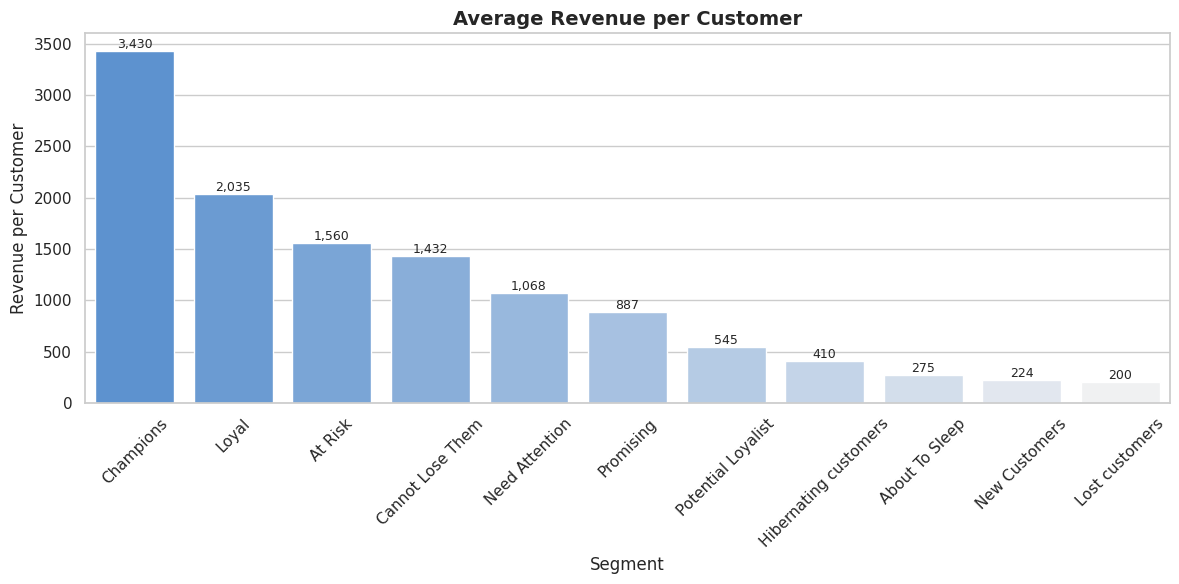

In [29]:
# Average Revenue per Customer

plt.figure(figsize=(12,6))

rev_per_customer = (
    rfm.groupby('Segment')['Monetary']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

palette = brand_palette(len(rev_per_customer), reverse=True)

ax = sns.barplot(
    data=rev_per_customer,
    x='Segment',
    y='Monetary',
    palette=palette
)

for p in ax.patches:
    ax.annotate(
        f'{p.get_height():,.0f}',
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.title("Average Revenue per Customer", fontsize=14, weight='bold')
plt.xlabel("Segment")
plt.ylabel("Revenue per Customer")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 📌 Insight  

- **Champions generate the highest revenue per customer (3,430)**, significantly outperforming Loyal (2,035) and At Risk (1,560), confirming their premium value.  

- High-value but vulnerable segments such as **Cannot Lose Them (1,432)** and **At Risk (1,560)** represent substantial revenue at potential churn risk.  

- Lower-tier segments like **Lost (200) and New Customers (224)** contribute minimal value per customer, highlighting the need for upselling rather than reactivation focus.

**6. CLV Proxy Calculation & Distribution**

Purpose: Estimate long-term customer value using RFM

CLV Proxy = Frequency*Monetary

In [30]:
# Create CLV proxy metric
rfm['CLV_Proxy'] = rfm['Frequency'] * rfm['Monetary']

**6.1 Customer Lifetime Value (CLV) Distribution**

Analyze the distribution of estimated customer lifetime value

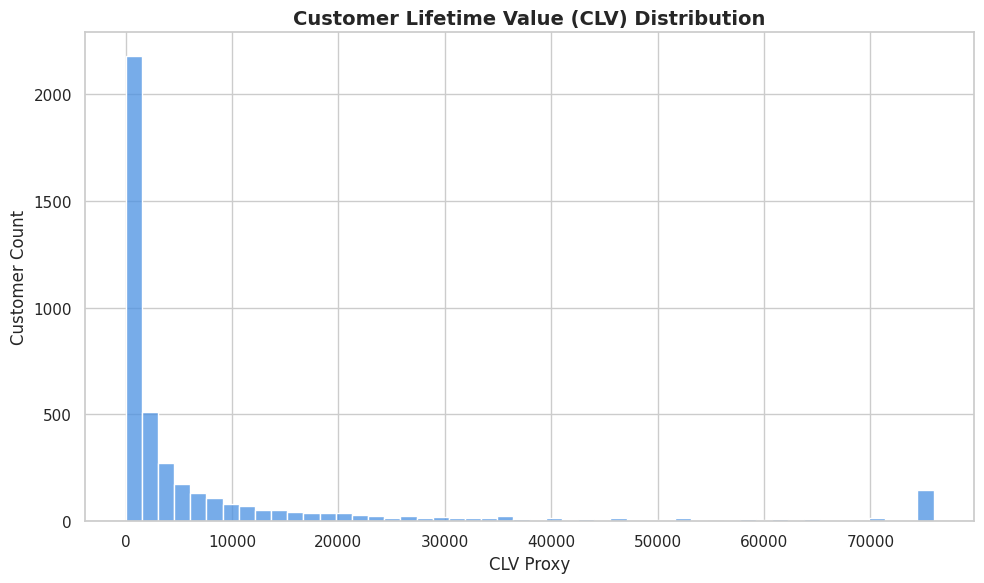

In [31]:
# CLV Distribution

plt.figure(figsize=(10,6))

sns.histplot(rfm['CLV_Proxy'], bins=50, color=Brand_color)

plt.title("Customer Lifetime Value (CLV) Distribution", fontsize=14, weight='bold')
plt.xlabel("CLV Proxy")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

📌 **Insight**

- The **CLV distribution is highly right-skewed**, with most customers at **low CLV** and a small group generating **exceptionally high value**.
- A limited number of **high-CLV customers** contribute disproportionately to total revenue, confirming strong **value concentration**.
- This pattern underscores the need to **prioritize retention of top-value customers** while applying targeted **upsell strategies** to mid-tier segments.

**6.2 CLV Comparison Across Segments**

Compare CLV distribution across different customer segments

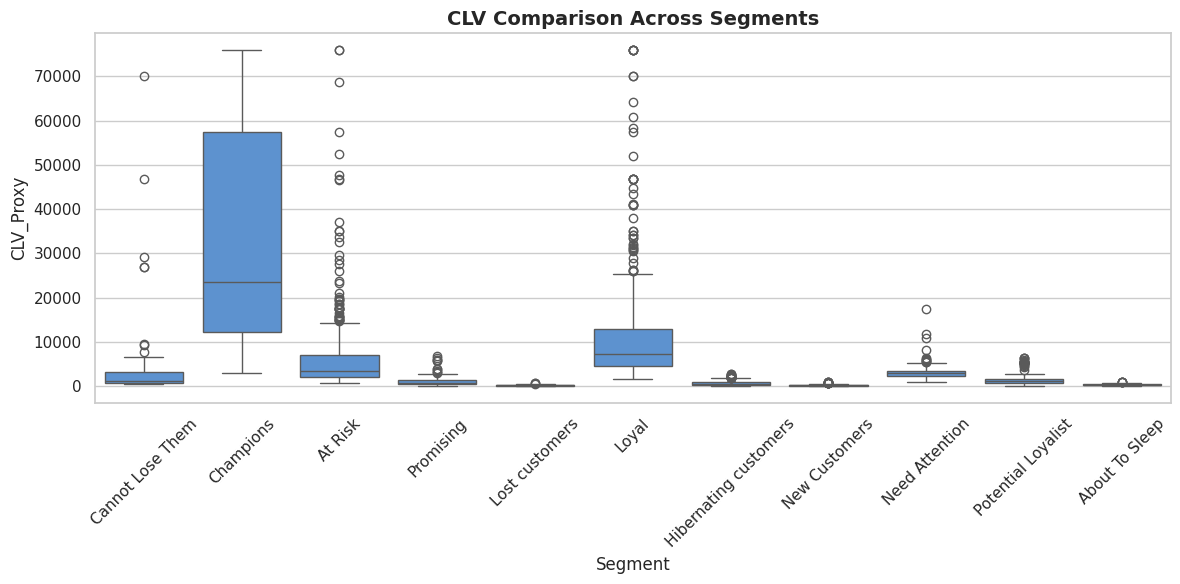

In [32]:
# CLV by Segment (Boxplot Comparison)

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Segment',
    y='CLV_Proxy',
    data=rfm,
    color=Brand_color
)

plt.xticks(rotation=45)
plt.title("CLV Comparison Across Segments", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

📌 **Insight**

- **Champions** exhibit the highest median **CLV** with a wide value spread, confirming their role as the primary long-term revenue drivers.
- **Loyal** and **At Risk** segments also show elevated CLV levels, indicating strong monetization potential but varying retention stability.
- In contrast, segments such as **New Customers**, **Hibernating**, and **About To Sleep** display consistently low CLV, reflecting limited current value.
- Overall, **customer lifetime value is highly concentrated** in a few key segments, reinforcing the need for differentiated retention and upsell strategies.

**7. Top 10% High CLV Customers**

Identify the top 10% customers with the highest lifetime value

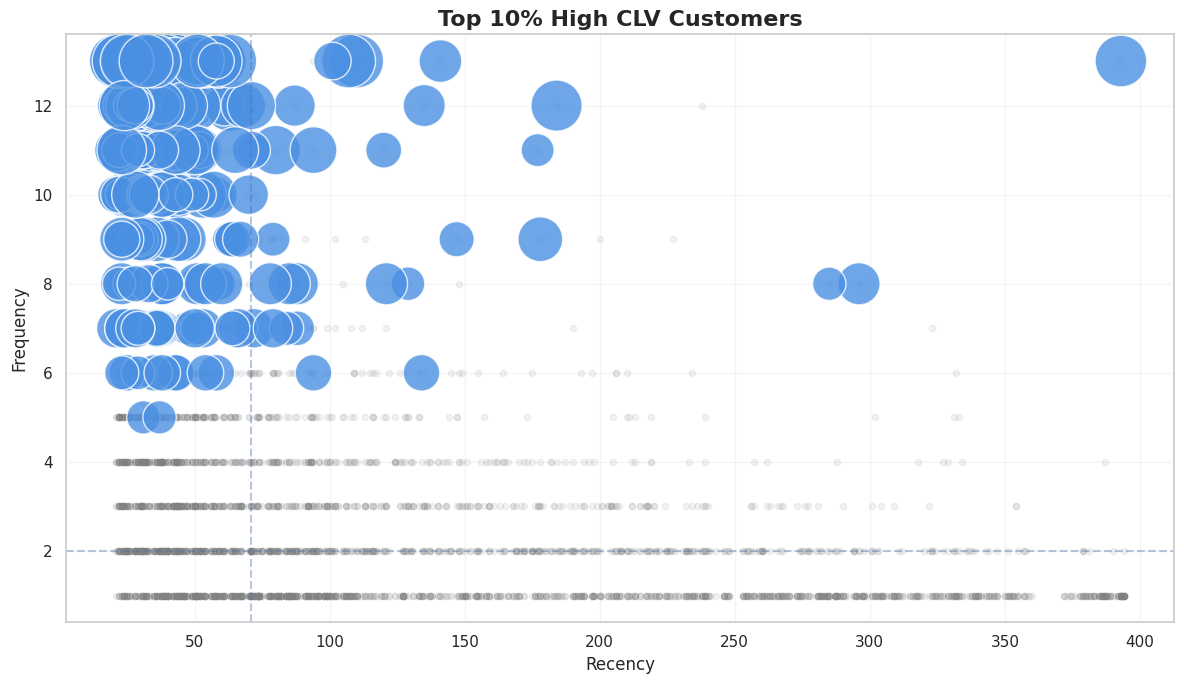

In [33]:
# Top 10% High CLV Customers Highlight

# Define top 10% threshold
threshold = rfm['CLV_Proxy'].quantile(0.90)
top_customers = rfm[rfm['CLV_Proxy'] >= threshold]

plt.figure(figsize=(12,7))

# Background customers (smaller + lighter)
plt.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    s=20,
    alpha=0.1,
    color='grey'
)

# Scale bubble size properly for top customers
scaled_size = (top_customers['CLV_Proxy'] /
               top_customers['CLV_Proxy'].max()) * 1500

# Highlight Top 10%
plt.scatter(
    top_customers['Recency'],
    top_customers['Frequency'],
    s=scaled_size,
    alpha=0.8,
    color=Brand_color,
    edgecolor='white',
    linewidth=1
)

# Add median reference lines
plt.axvline(rfm['Recency'].median(), linestyle='--', alpha=0.4)
plt.axhline(rfm['Frequency'].median(), linestyle='--', alpha=0.4)

plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.title("Top 10% High CLV Customers", fontsize=16, weight='bold')

plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

📌 **Insight**

- The **top 10% high-CLV customers** are primarily concentrated in the **low Recency – high Frequency** zone, indicating strong engagement and repeat purchasing behavior.
- These customers represent the core **revenue-driving segment** and should be prioritized for retention and loyalty programs.
- Protecting this small but valuable group is critical to sustaining long-term revenue performance.

**C. Risk & Retention Analysis**

Analyzing churn risk to identify customers who may require retention strategies.

**8. Churn Risk Scoring**

Purpose: Identify customers with high probability of churn

Simple approach: Higher Recency → Higher churn risk

In [34]:
# Normalize Recency (scale between 0 and 1)
rfm['R_scaled'] = rfm['Recency'] / rfm['Recency'].max()

# Define churn score (higher Recency = higher risk)
rfm['Churn_Score'] = rfm['R_scaled']

**8.1 Customer Churn Risk Distribution**

Visualize the distribution of churn risk among customers

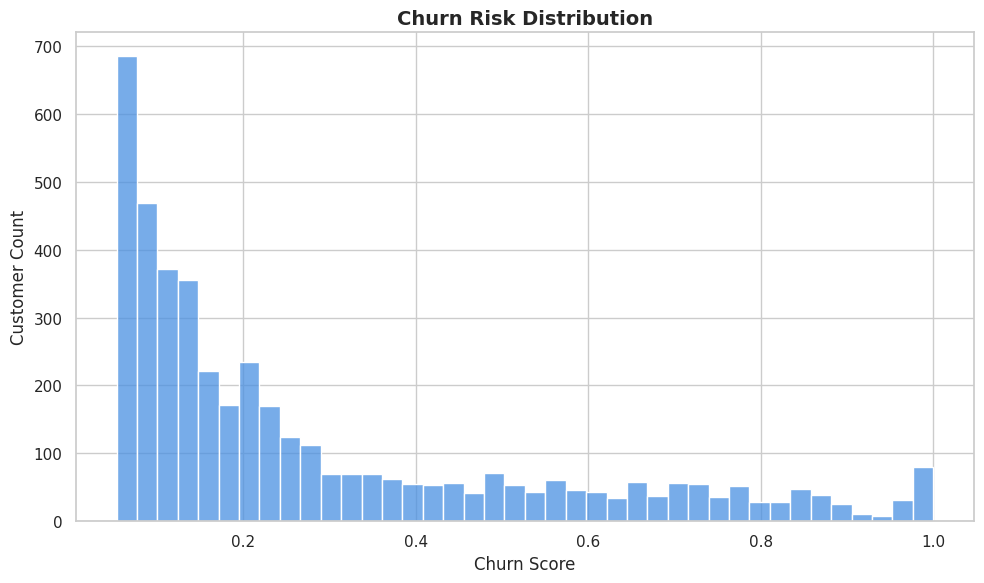

In [35]:
# Churn Risk Distribution

plt.figure(figsize=(10,6))

sns.histplot(rfm['Churn_Score'], bins=40, color=Brand_color)

plt.title("Churn Risk Distribution", fontsize=14, weight='bold')
plt.xlabel("Churn Score")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

📌 **Insight**

- The churn risk distribution is right-skewed, with the majority of customers concentrated at **low churn scores (below 0.3)**, indicating a relatively stable customer base.
- However, a noticeable tail of customers exhibits **high churn risk (above 0.7)**, representing a vulnerable segment that may require immediate retention actions.
- Although smaller in size, this high-risk group could pose significant revenue impact if it overlaps with high-value segments.
- Overall, churn risk is not evenly distributed, highlighting the importance of targeted, segment-based retention strategies.

**8.2 Churn Risk by Customer Segment**

Evaluate which segments have the highest risk of churn

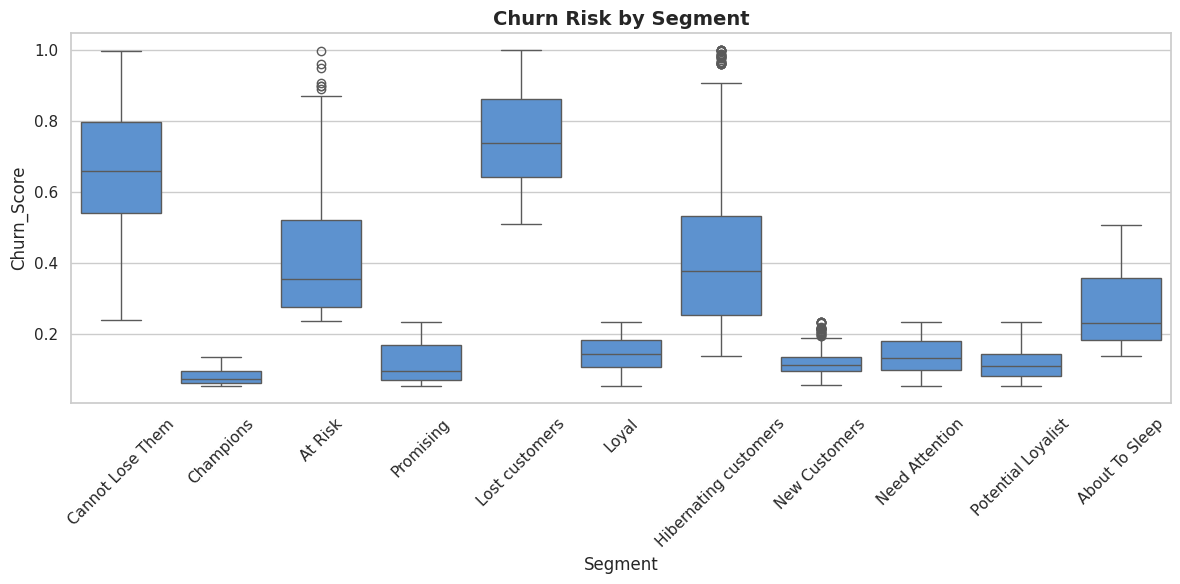

In [36]:
# Churn Risk by Segment

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Segment',
    y='Churn_Score',
    data=rfm,
    color=Brand_color
)

plt.xticks(rotation=45)
plt.title("Churn Risk by Segment", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

📌 **Insight**

- **Lost Customers** and **Cannot Lose Them** segments show the highest median churn scores (around 0.6–0.8), indicating severe disengagement and immediate revenue risk.
- **At Risk** customers also display elevated churn levels with wide variability, suggesting urgent retention opportunities with potentially high ROI.
- In contrast, **Champions** and **Loyal** segments maintain consistently low churn scores, confirming strong engagement and customer stability.
- Churn risk is clearly segment-driven rather than evenly distributed, reinforcing the value of RFM-based targeted retention strategies.

**D. Strategic Marketing Insights**

Supporting marketing decision-making through strategic customer analysis.

**9. Pareto Analysis of Revenue Contribution (80/20 Rule)**

Identify the proportion of customers contributing to total revenue

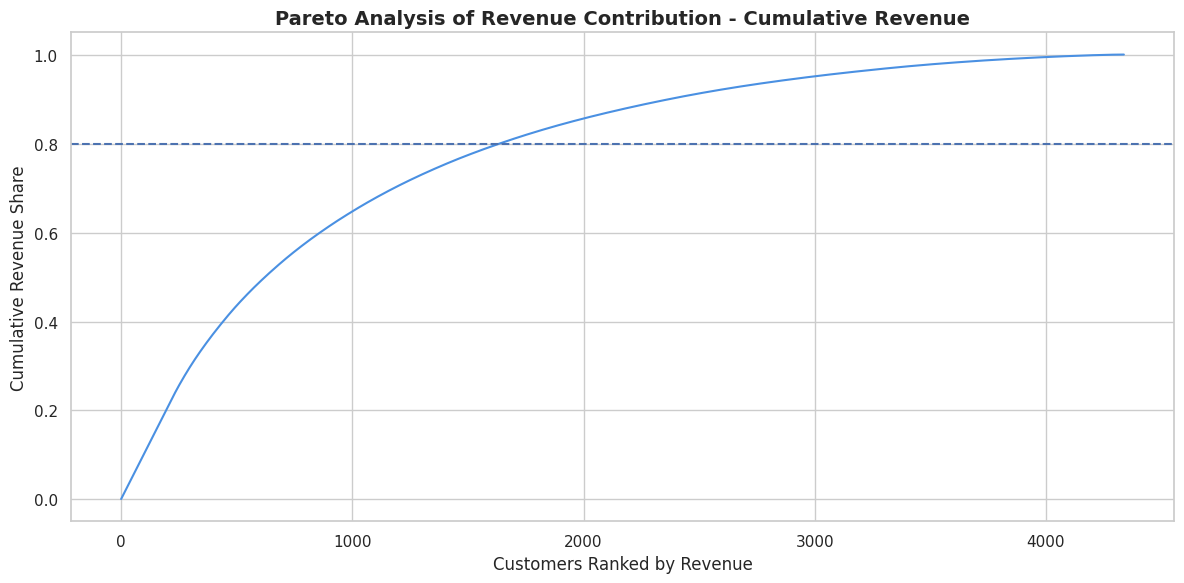

In [37]:
# Pareto Analysis

plt.figure(figsize=(12,6))

rfm_sorted = rfm.sort_values(by='Monetary', ascending=False)
rfm_sorted['Cum_Percent'] = (
    rfm_sorted['Monetary'].cumsum() /
    rfm_sorted['Monetary'].sum()
)

plt.plot(rfm_sorted['Cum_Percent'].values, color=Brand_color)
plt.axhline(y=0.8, linestyle='--')

plt.title("Pareto Analysis of Revenue Contribution - Cumulative Revenue", fontsize=14, weight='bold')
plt.xlabel("Customers Ranked by Revenue")
plt.ylabel("Cumulative Revenue Share")
plt.tight_layout()
plt.show()

### 📌 Insight  

- Approximately **20–25% of customers generate nearly 80% of total revenue**, confirming a strong Pareto (80/20) effect.  

- Revenue is highly concentrated among top-spending customers, indicating significant dependence on a relatively small customer base.  

- Protecting and retaining high-value customers is critical, as losing a small portion of them could materially impact total revenue.

**10. RFM Customer Behavior Distribution**

Visualize customer behavior based on Recency, Frequency, and Monetary values

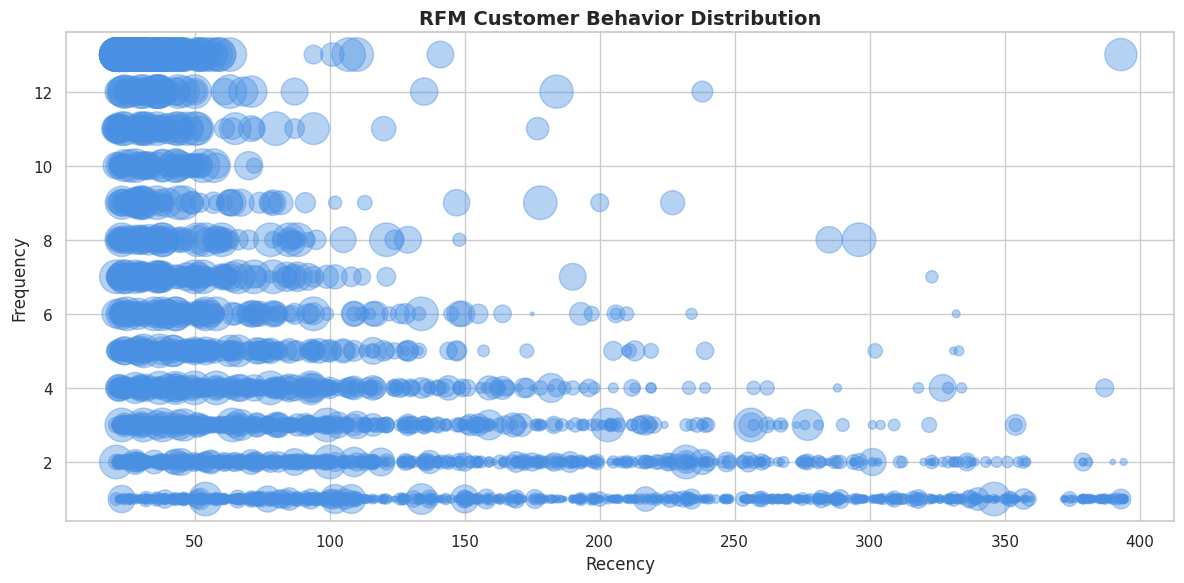

In [38]:
# RFM Distribution Bubble Chart

plt.figure(figsize=(12,6))

plt.scatter(
    rfm['Recency'],
    rfm['Frequency'],
    s=rfm['Monetary']/10,
    alpha=0.4,
    color=Brand_color
)

plt.title("RFM Customer Behavior Distribution", fontsize=14, weight='bold')
plt.xlabel("Recency")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

### 📌 Insight  

- High-value customers (larger bubbles) are concentrated in the **low Recency – high Frequency** zone, indicating that recent and frequent buyers drive the majority of revenue.  

- A large portion of customers cluster in the **high Recency – low Frequency** area, suggesting a substantial inactive or low-engagement base.  

- Revenue distribution is uneven, with a small group of active customers generating disproportionately higher monetary value.

**11. Segment Priority Matrix**

This chart compares customer share vs revenue share of each segment. Bubble size represents total revenue.

Helps identify high-value segments that generate disproportionate revenue

In [43]:
pip install adjustText

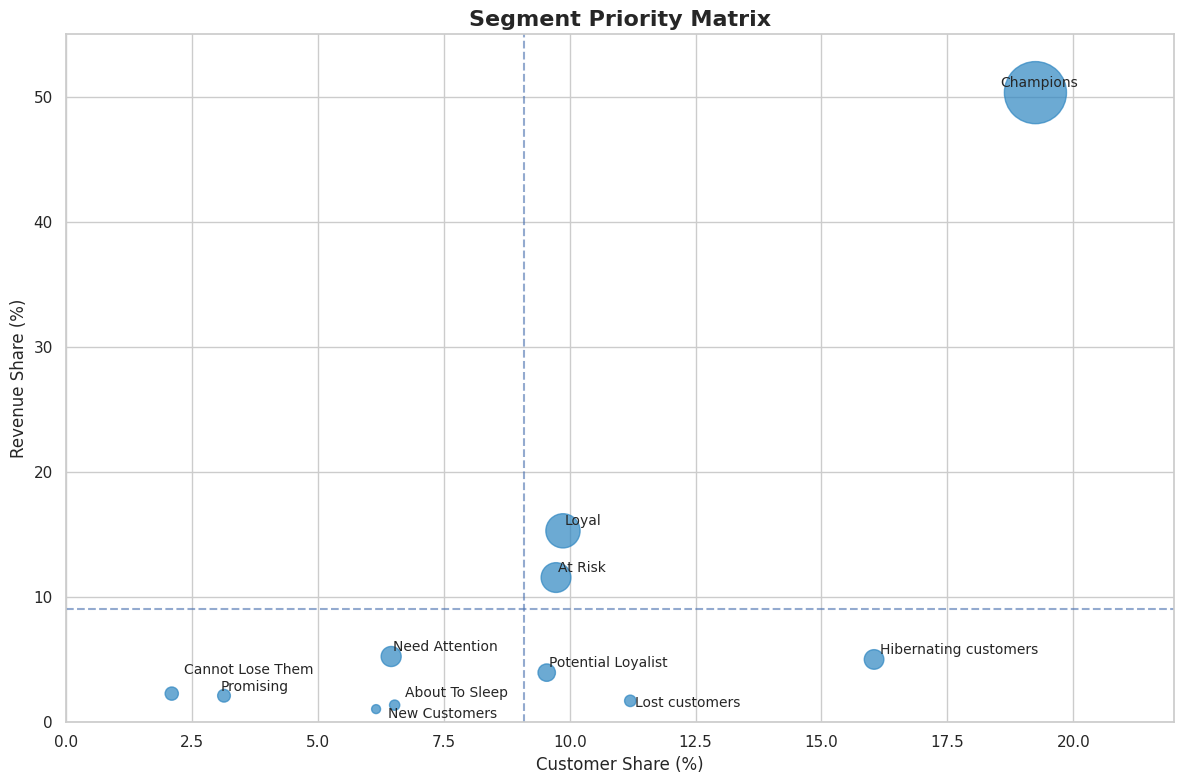

In [44]:
from adjustText import adjust_text

sns.set(style="whitegrid")

# Segment Summary
segment_summary = (
    rfm.groupby('Segment')
    .agg(Customer_Count=('CustomerID','count'),
         Revenue=('Monetary','sum'))
    .reset_index()
)

segment_summary['Customer_Share'] = segment_summary['Customer_Count'] / segment_summary['Customer_Count'].sum()
segment_summary['Revenue_Share'] = segment_summary['Revenue'] / segment_summary['Revenue'].sum()

bubble_size = segment_summary['Revenue'] / segment_summary['Revenue'].max() * 2000


# Segment Priority Matrix
plt.figure(figsize=(12,8))

x = segment_summary['Customer_Share'] * 100
y = segment_summary['Revenue_Share'] * 100

plt.scatter(x, y, s=bubble_size, alpha=0.7, color="#2E86C1")


# Labels
texts = [
    plt.text(x[i], y[i], segment_summary['Segment'][i], fontsize=10)
    for i in range(len(segment_summary))
]

adjust_text(texts)


# Quadrant reference lines
plt.axhline(y.mean(), linestyle='--', alpha=0.6)
plt.axvline(x.mean(), linestyle='--', alpha=0.6)


# Axis & Title
plt.xlabel("Customer Share (%)")
plt.ylabel("Revenue Share (%)")
plt.title("Segment Priority Matrix", fontsize=16, weight='bold')

plt.xlim(0,22)
plt.ylim(0,55)

plt.tight_layout()
plt.show()

📌 **Insight**

- **Champions (~20% of customers)** generate approximately **50% of total revenue**, confirming strong revenue concentration and the need for priority retention strategies.
- **Loyal and At Risk segments (~10% each)** together contribute around **25–30% of revenue**, indicating significant churn sensitivity and high retention ROI.
- In contrast, **Hibernating customers (~16% of customers)** contribute only **~4–5% of revenue**, highlighting substantial reactivation potential.
- Overall, nearly **75–80% of revenue** is driven by a small group of high-value segments, reinforcing the importance of targeted, data-driven marketing actions.

## Executive Insight & Strategic Direction

## Overall Business Insight

SuperStore’s revenue structure is **highly concentrated and engagement-driven**.  

Approximately **20–25% of customers generate 75–80% of total revenue**, with **Champions (~20% of the base) contributing ~50% alone**. These high-value customers are characterized by **low Recency and high Frequency**, confirming that recent and repeat purchasing behavior is the primary driver of lifetime value.

Meanwhile, inactive segments such as **Hibernating and Lost (~27% of customers)** contribute minimal revenue but represent meaningful reactivation potential. In addition, **At Risk and Cannot Lose Them segments combine high monetary value with elevated churn scores**, exposing substantial revenue to potential loss.

This indicates that holiday marketing should not be mass-oriented, but **precision-driven and segment-specific**.

---

## Strategic Priorities for Holiday Campaign

## 1️⃣ Revenue Protection (Top Priority)

**Target:** Champions & Loyal  

- Represent ~50–65% of total revenue.
- Low churn risk but extremely high financial impact if lost.

**Strategy:**
- VIP holiday rewards & exclusive access
- Loyalty tier upgrades
- Personalized appreciation campaigns

Goal → Protect the revenue core during peak season.

---

## 2️⃣ Revenue Growth Acceleration

**Target:** Loyal, Potential Loyalists, At Risk  

- Contribute ~25–30% of revenue.
- Strong spending capacity but retention-sensitive.

**Strategy:**
- Holiday bundles & cross-sell promotions
- Time-limited festive incentives
- Early re-engagement triggers for rising Recency

Goal → Convert mid-tier customers into future Champions.

---

## 3️⃣ Churn Mitigation & Revenue Recovery

**Target:** At Risk, Cannot Lose Them, Hibernating  

- High churn scores with meaningful revenue exposure.
- Represent both revenue risk and recovery opportunity.

**Strategy:**
- Win-back holiday vouchers
- Personalized reminder campaigns
- Behavioral-triggered discount offers

Goal → Reduce revenue leakage and reactivate dormant value pools.

---

## Strategic Conclusion

SuperStore should shift from broad holiday promotions to a **data-driven, RFM-based marketing execution model**.

By simultaneously protecting high-value customers, accelerating mid-tier growth, and mitigating churn risk, the company can maximize short-term holiday ROI while strengthening long-term customer lifetime value.